# Fast Agent - Build a SQL Agent fast!

<img src="./assets/LC_L1_top.png" align="left" width="500">

## Setup

Load and/or check for needed environmental variables

In [1]:
from dotenv import load_dotenv
from env_utils import doublecheck_env, doublecheck_pkgs

# Load environment variables from .env
load_dotenv()

# Check and print results
doublecheck_env("example.env")  # check environmental variables
doublecheck_pkgs(pyproject_path="pyproject.toml", verbose=True)   # check packages

OPENAI_API_KEY=****W_MA
LANGSMITH_API_KEY=****cff7
LANGSMITH_TRACING=<not set>
LANGSMITH_PROJECT=<not set>
Python 3.11.15 satisfies requires-python: >=3.11,<3.14
package                | required | installed | status | path                                  
---------------------- | -------- | --------- | ------ | --------------------------------------
langgraph              | >=1.0.0  | 1.2.4     | ✅ OK   | /opt/venv/lib/python3.11/site-packages
langchain              | >=1.0.0  | 1.3.7     | ✅ OK   | /opt/venv/lib/python3.11/site-packages
langchain-core         | >=1.0.0  | 1.4.3     | ✅ OK   | /opt/venv/lib/python3.11/site-packages
langchain-openai       | >=1.1.14 | 1.3.0     | ✅ OK   | /opt/venv/lib/python3.11/site-packages
langchain-anthropic    | >=1.0.0  | 1.4.4     | ✅ OK   | /opt/venv/lib/python3.11/site-packages
langchain-community    | >=0.4    | 0.4.2     | ✅ OK   | /opt/venv/lib/python3.11/site-packages
jupyter                | >=1.0.0  | 1.1.1     | ✅ OK   | /opt/venv/lib

In [2]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

/tmp/ipykernel_2766/3731249078.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


In [3]:
db

Define the runtime context to provide the agent and tools with access to the database.

In [4]:
from dataclasses import dataclass

from langchain_community.utilities import SQLDatabase


# define context structure to support dependency injection
@dataclass
class RuntimeContext:
    db: SQLDatabase

<b>⚠️ Security Note:</b> This demo does not include a filter on LLM-generated commands. In production, you would want to limit the scope of LLM-generated commands. ⚠️   
This tool will connect to the database. Note the use of `get_runtime` to access the graph **runtime context**.

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

Add a system prompt to define your agents behavior.

In [6]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows of output unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

Create your agent! Add a model, tools, a prompt, and the runtime access, and go!  You can choose many agents from our [integrations](https://docs.langchain.com/oss/python/integrations/providers) list. 

In [7]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI # Ensure this is installed

agent = create_agent(
    # Swap out "openai:gpt-5-mini" for the Gemini model string shortcut
    model="google_genai:gemini-2.5-flash",
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Here's a display of the agent ReAct Loop.

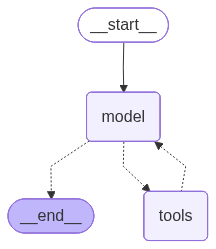

In [8]:
from IPython.display import Image, display

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

Run some queries. Notice:
- The agent does not have the database schema and will need to discover it independently.
- The agent may make mistakes! By returning error messages, the agent can self-correct its queries.
- Notice you invoke the agent with `agent.stream`.
    - This command and the `pretty_print` display the **messages** that communicate information between the model and the tools.
- Notice the agent doesn't remember the schema between invocations... More on this later!

In [9]:
question = "Which table has the largest number of entries?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which table has the largest number of entries?


================================== Ai Message ==================================
Tool Calls:
  execute_sql (285bd070-4ac4-4b71-854c-ccae0c6722df)
 Call ID: 285bd070-4ac4-4b71-854c-ccae0c6722df
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (d0714e24-3d78-4672-92e9-7210e098d1d6)
 Call ID: d0714e24-3d78-4672-92e9-7210e098d1d6
  Args:
    query: SELECT COUNT(*) FROM Album;
================================= Tool Message =================================
Name: execute_sql

[(347,)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (173aec6d-0a59-4f3

In [10]:
question = "Which genre on average has the longest tracks?"

for step in agent.stream(
    {"messages": question},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Which genre on average has the longest tracks?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (b490493d-ec05-4f3e-bb7c-61127402d8f5)
 Call ID: b490493d-ec05-4f3e-bb7c-61127402d8f5
  Args:
    query: SELECT g.Name AS Genre, AVG(t.Milliseconds) AS AverageTrackLength FROM tracks AS t JOIN genres AS g ON t.GenreId = g.GenreId GROUP BY g.Name ORDER BY AverageTrackLength DESC LIMIT 1;
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: tracks
[SQL: SELECT g.Name AS Genre, AVG(t.Milliseconds) AS AverageTrackLength FROM tracks AS t JOIN genres AS g ON t.GenreId = g.GenreId GROUP BY g.Name ORDER BY AverageTrackLength DESC LIMIT 1;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message =======================

In [11]:
question = "Please list all of the tables"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all of the tables
================================== Ai Message ==================================
Tool Calls:
  execute_sql (1554de15-5388-4f8f-91c5-9a70488d6aeb)
 Call ID: 1554de15-5388-4f8f-91c5-9a70488d6aeb
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The tables in the database are: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, and Track.', 'extras': {'signature': 'CpUBAQw51se1sCc8w517j8pwkbtsMLRH/mzx+NeDDnjSZm6VUroyUD2WSaeZcfX8B9QLSw0JblV2S3EXJYl

**Create your own query here!**  Add some questions of your own.

In [14]:
question = "Please list all the tables in the database"

for step in agent.stream(
    {"messages": question},
    context={"db": db},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Please list all the tables in the database
================================== Ai Message ==================================
Tool Calls:
  execute_sql (cc24ff85-c7f3-419d-aa03-2843d2917c92)
 Call ID: cc24ff85-c7f3-419d-aa03-2843d2917c92
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table';
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================

[{'type': 'text', 'text': 'The tables in the database are: Album, Artist, Customer, Employee, Genre, Invoice, InvoiceLine, MediaType, Playlist, PlaylistTrack, and Track.', 'extras': {'signature': 'Cq0BAQw51sc2MeqBxN43/+WgM/RrSq5T1rJ2zo3BfUtj4YLQDwxrdne4OrSbtcTwvGzOQ7

### Let's try this Studio